# Flood Guard — EDA: Training Dataset

**Step 3** of the ML pipeline: inspect `training_data.csv` before training anything.

We're looking for three things:
1. **Class balance** — how rare is `flood_label = 1`, and does that match what `data_prep/build_dataset.py` reported?
2. **Feature distributions** — are the rolling precipitation features sane, and how skewed are they (most hours have zero rain)?
3. **Seasonal patterns** — do floods cluster around Kampala's known rainy seasons (Mar–May, Oct–Nov)? If yes, `month` is a genuinely useful feature, not noise.

Dataset: 144,577 hourly rows, 2010–2026, built from ERA5 via Open-Meteo, station = kampala_city_centre.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_PATH = "../datasets/training_data.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
print(f"shape: {df.shape}")
df.head()

shape: (144577, 9)


,timestamp,precip_3h,precip_6h,precip_12h,precip_24h,max_precip_1h_in_6h,relative_humidity_pct,month,flood_label
0,2010-01-01 23:00:00,0.0,0.0,3.5,9.8,0.0,89,1,0
1,2010-01-02 00:00:00,0.0,0.0,3.2,9.8,0.0,90,1,0
2,2010-01-02 01:00:00,0.0,0.0,2.3,9.8,0.0,92,1,0
3,2010-01-02 02:00:00,0.7,0.7,1.1,10.5,0.7,93,1,0
4,2010-01-02 03:00:00,1.4,1.4,1.4,11.2,0.7,94,1,0


## Missing values & summary stats

The dataset comes from `engineer_features()` in `build_dataset.py`, which already `dropna()`s
rows with incomplete rolling windows — so we expect **zero** missing values here. This is a
sanity check that assumption held.

In [2]:
print("Missing values per column:")
print(df.isna().sum())
print()
df.describe()

Missing values per column:
timestamp                0
precip_3h                0
precip_6h                0
precip_12h               0
precip_24h               0
max_precip_1h_in_6h      0
relative_humidity_pct    0
month                    0
flood_label              0
dtype: int64



,timestamp,precip_3h,precip_6h,precip_12h,precip_24h,max_precip_1h_in_6h,relative_humidity_pct,month,flood_label
count,144577,144577.000000,144577.000000,144577.000000,144577.000000,144577.000000,144577.000000,144577.000000,144577.000000
mean,2018-04-01 23:00:00,0.498563,0.997125,1.994295,3.989028,0.599758,81.502099,6.433229,0.020197
min,2010-01-01 23:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,1.000000,0.000000
25%,2014-02-15 23:00:00,0.000000,0.000000,0.000000,0.700000,0.000000,74.000000,3.000000,0.000000
50%,2018-04-01 23:00:00,0.000000,0.100000,0.600000,2.400000,0.100000,84.000000,6.000000,0.000000
75%,2022-05-16 23:00:00,0.300000,1.000000,2.800000,5.900000,0.600000,92.000000,9.000000,0.000000
max,2026-06-30 23:00:00,72.400000,114.300000,127.000000,127.000000,27.300000,100.000000,12.000000,1.000000
std,NaN,1.345566,2.139915,3.248178,4.740327,1.231642,13.079229,3.447635,0.140674


## Class balance

`build_dataset.py` reported **2,920 positive rows (2.02%)** out of 144,577 after the
threshold was tuned down from 30mm/3h to 5mm/3h (ERA5's ~25km grid spatially averages
rainfall, so the literal Uganda Met Authority threshold was almost never reached). Confirming
that number here, and visualizing just how imbalanced this is.

flood_label
0    141657
1      2920
Name: count, dtype: int64
flood_label
0    97.98
1     2.02
Name: proportion, dtype: float64


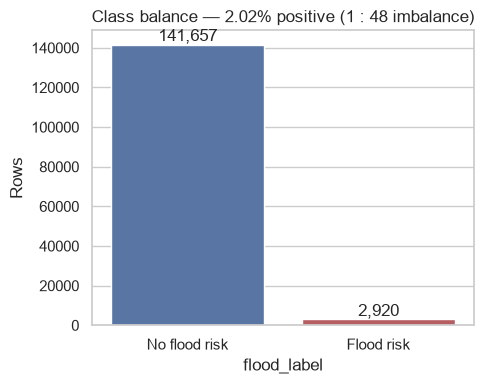

In [3]:
counts = df["flood_label"].value_counts().sort_index()
pct = df["flood_label"].value_counts(normalize=True).sort_index() * 100

print(counts)
print(pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index.map({0: "No flood risk", 1: "Flood risk"}), y=counts.values, ax=ax,
            hue=counts.index, palette=["#4C72B0", "#C44E52"], legend=False)
ax.set_ylabel("Rows")
ax.set_title(f"Class balance — {pct[1]:.2f}% positive (1 : {int(counts[0] / counts[1])} imbalance)")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Takeaway:** ~1:49 imbalance confirmed. This is expected — flood-level rain is rare by
definition — and it's why Step 4 needs `class_weight='balanced'` (RF/SVM) or
`scale_pos_weight` (XGBoost/LightGBM) rather than plain accuracy-driven training.

## Feature distributions

All the rolling precipitation features (`precip_3h` … `precip_24h`, `max_precip_1h_in_6h`)
should be heavily right-skewed: most hours in Kampala have no rain at all, and only a small
tail has heavy accumulation.

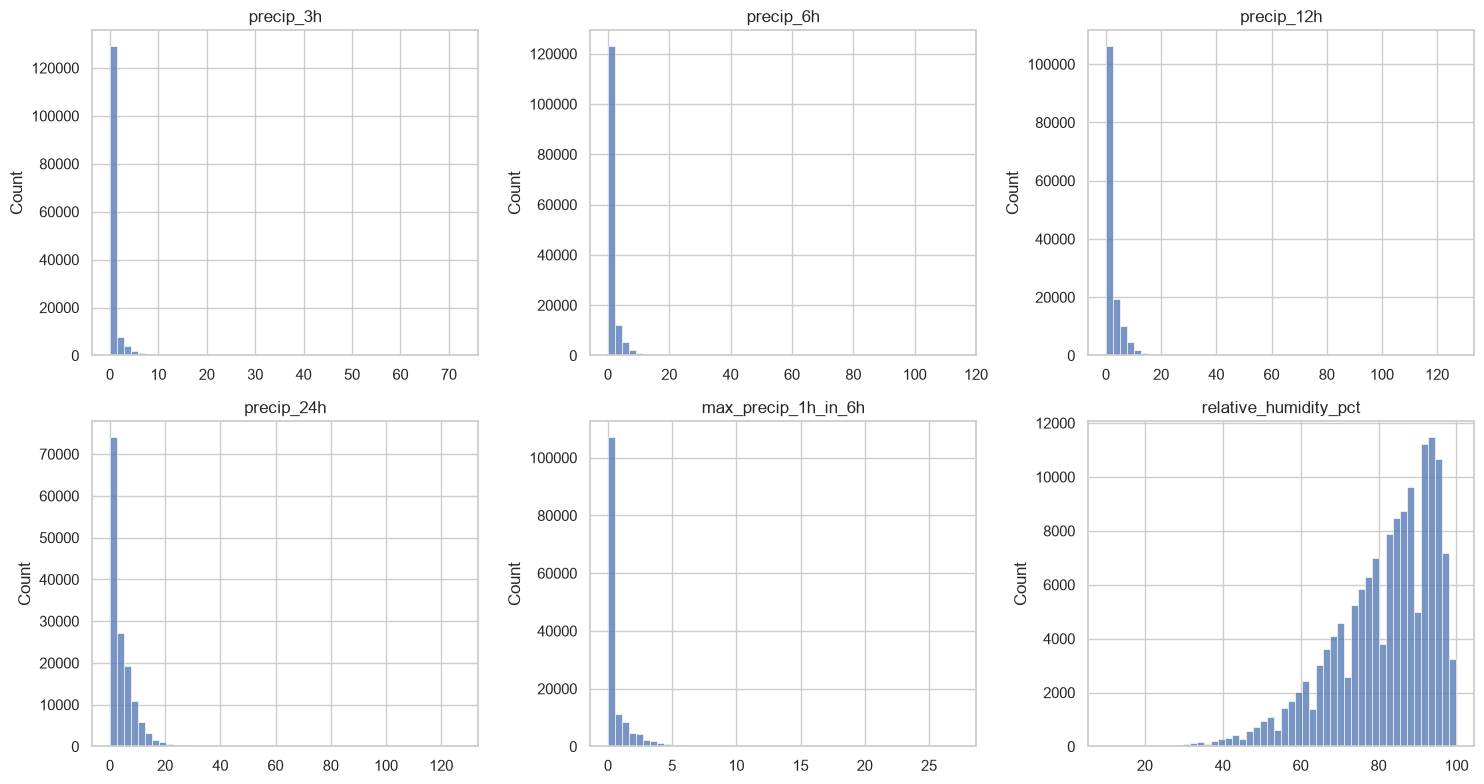

In [4]:
numeric_features = [
    "precip_3h", "precip_6h", "precip_12h", "precip_24h",
    "max_precip_1h_in_6h", "relative_humidity_pct",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_features):
    sns.histplot(df[col], bins=50, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

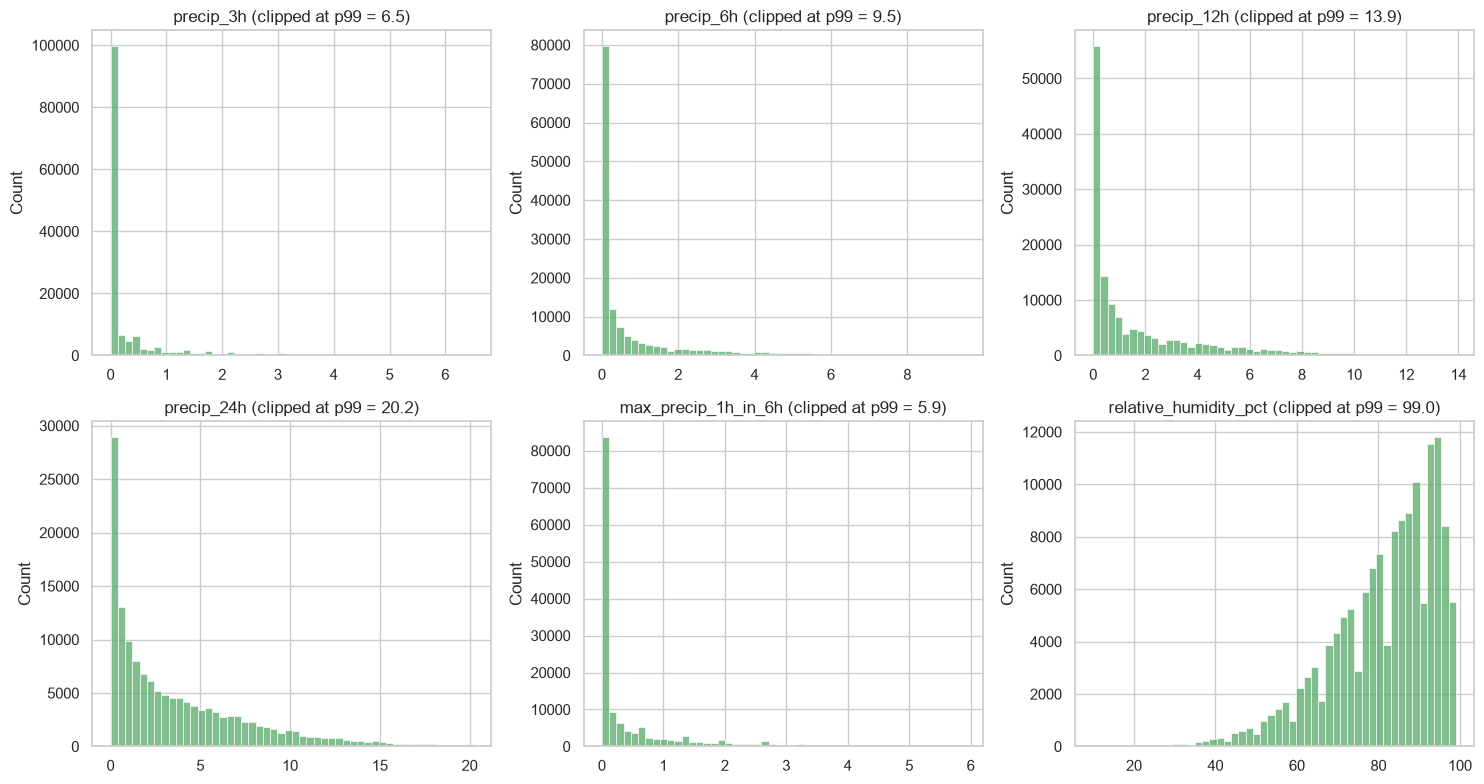

In [5]:
# Zoomed view, clipped to the 99th percentile, so the rain features aren't
# all-but-invisible next to the zero-heavy bulk of the distribution.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_features):
    clip = df[col].quantile(0.99)
    sns.histplot(df[df[col] <= clip][col], bins=50, ax=ax, color="#55A868")
    ax.set_title(f"{col} (clipped at p99 = {clip:.1f})")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Feature distributions by flood label

Do the rain features actually separate flood hours from normal hours? If flood rows don't
look different from non-flood rows on these features, the model has nothing to learn from.

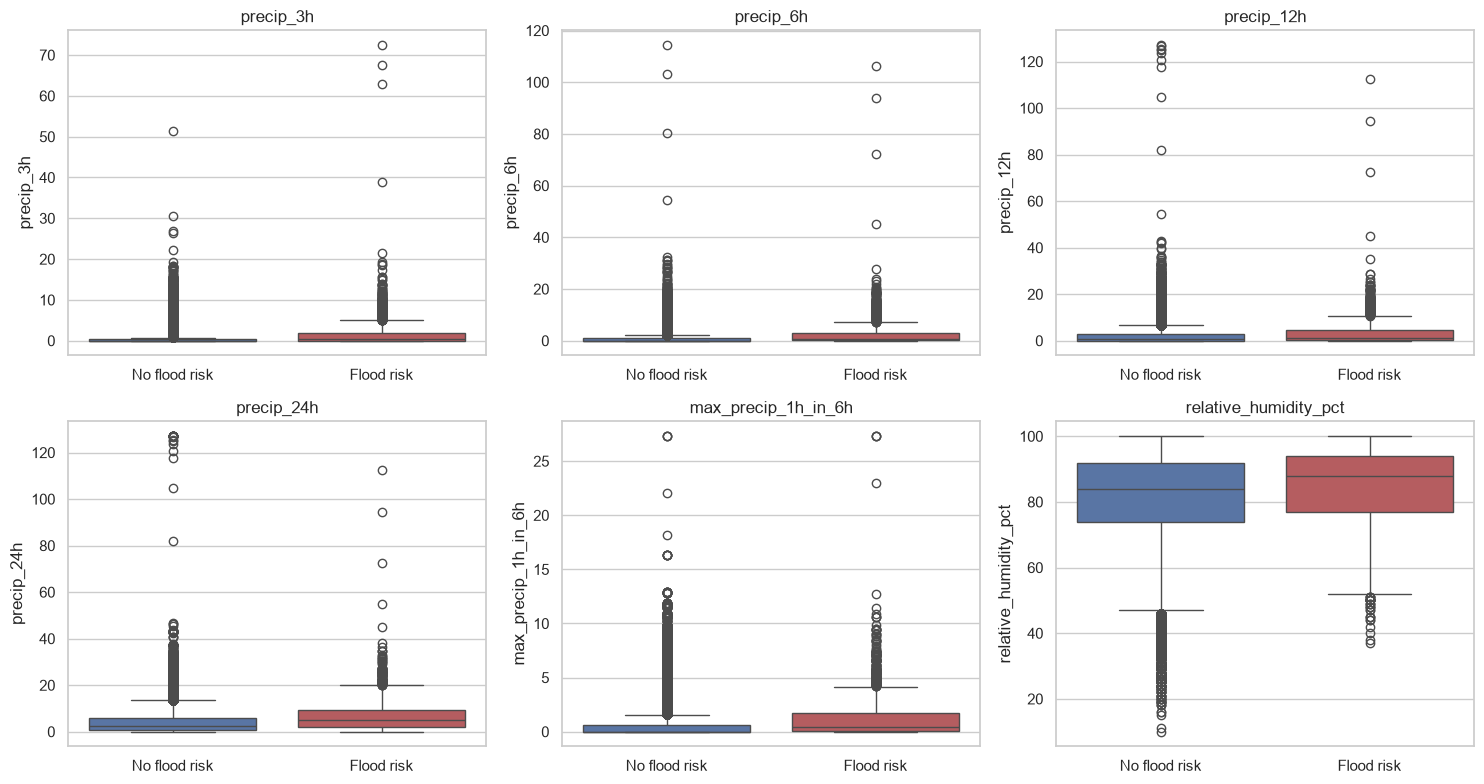

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_features):
    sns.boxplot(data=df, x="flood_label", y=col, ax=ax,
                hue="flood_label", palette=["#4C72B0", "#C44E52"], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No flood risk", "Flood risk"])
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [7]:
print("Correlation of each feature with flood_label:")
df.corr(numeric_only=True)["flood_label"].sort_values(ascending=False)

Correlation of each feature with flood_label:


flood_label              1.000000
precip_3h                0.120214
precip_6h                0.089213
precip_24h               0.081290
max_precip_1h_in_6h      0.072154
precip_12h               0.052435
relative_humidity_pct    0.035807
month                    0.011765
Name: flood_label, dtype: float64

**Takeaway:** every precipitation feature is positively correlated with `flood_label`, as
expected. `precip_3h` (short-burst rain) correlates most strongly (0.12) — *stronger* than the
longer accumulation windows like `precip_24h` (0.08). That matches the physical intuition
baked into `build_dataset.py`'s docstring: a short, intense burst is what triggers the 3-hour
flood label, not slow accumulation. Correlations look modest in absolute terms because a
single linear coefficient can't capture how these features interact — that's exactly what the
Step 4 models (trees, boosting) are for.

## Seasonal patterns

Kampala has two rainy seasons: March–May and October–November. If `month` is a useful
feature, flood rate should visibly spike in those windows.

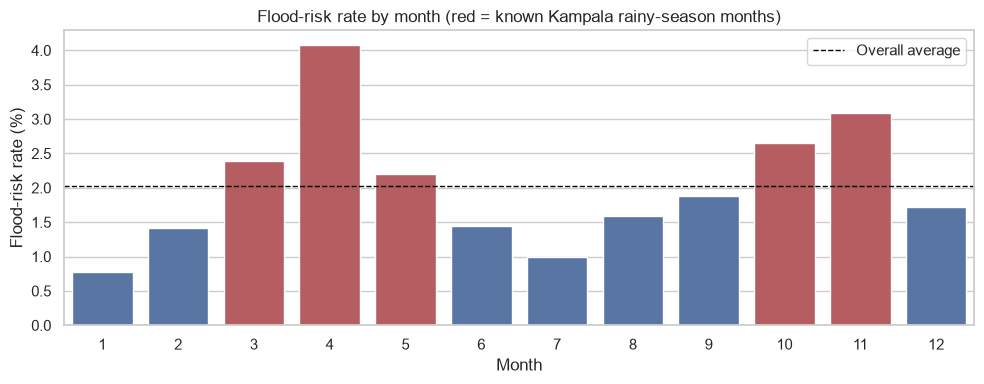

month
1     0.78
2     1.41
3     2.39
4     4.08
5     2.21
6     1.45
7     1.00
8     1.60
9     1.88
10    2.65
11    3.09
12    1.72
Name: flood_label, dtype: float64

In [8]:
monthly_rate = df.groupby("month")["flood_label"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#C44E52" if m in (3, 4, 5, 10, 11) else "#4C72B0" for m in monthly_rate.index]
sns.barplot(x=monthly_rate.index, y=monthly_rate.values, hue=monthly_rate.index,
            palette=colors, legend=False, ax=ax)
ax.set_xlabel("Month")
ax.set_ylabel("Flood-risk rate (%)")
ax.set_title("Flood-risk rate by month (red = known Kampala rainy-season months)")
ax.axhline(df["flood_label"].mean() * 100, color="black", linestyle="--", linewidth=1,
           label="Overall average")
ax.legend()
plt.tight_layout()
plt.show()

monthly_rate.round(2)

**Takeaway:** April (4.08%) and November (3.09%) are the two clearest peaks, and March/May/October
are all above the 2.02% overall average — a good match to the expected Mar–May and Oct–Nov rainy
seasons. `month` carries real signal, not just noise; it's earning its place as a feature.

## Time series view

A direct look at `precip_24h` over time with flood-risk hours marked, to sanity-check that
labeled events look like real weather (clustered rainy spells), not scattered artifacts.

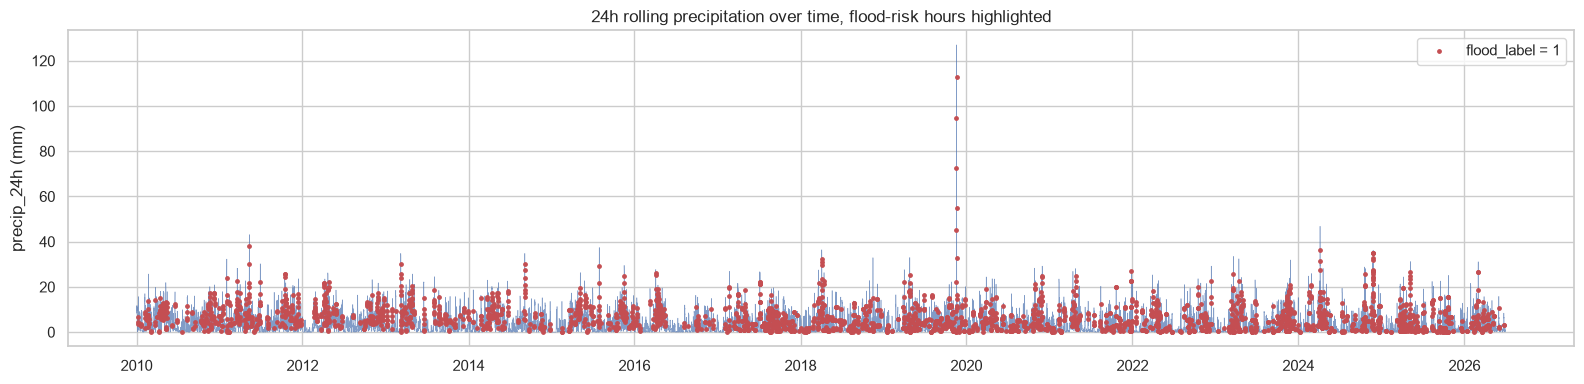

In [9]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df["timestamp"], df["precip_24h"], linewidth=0.4, color="#4C72B0", alpha=0.7)
flood_rows = df[df["flood_label"] == 1]
ax.scatter(flood_rows["timestamp"], flood_rows["precip_24h"], color="#C44E52", s=6,
           label="flood_label = 1", zorder=3)
ax.set_ylabel("precip_24h (mm)")
ax.set_title("24h rolling precipitation over time, flood-risk hours highlighted")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

- **No missing values** — the dataset is clean going into Step 4.
- **Severe class imbalance**: 2,920 / 144,577 rows (2.02%) are flood-risk, a 1:49 ratio.
  Step 4 training must use `class_weight='balanced'` (RF/SVM) or `scale_pos_weight`
  (XGBoost/LightGBM) — plain accuracy would let a model score ~98% by predicting "no flood"
  every time.
- **Rain features separate the classes** as expected, with `precip_3h` (short burst) the
  single strongest linear signal — stronger than the longer accumulation windows.
- **Seasonality is real**: flood rate roughly doubles in April/November versus the yearly
  average, consistent with Kampala's two rainy seasons. `month` is a legitimate feature.
- Flood-risk hours in the time series plot cluster in visible rainy spells rather than
  appearing as scattered noise — the labeling logic looks sound.

**Next: Step 4** — train RF, SVM, XGBoost, and LightGBM with class balancing, using this
feature set: `precip_3h`, `precip_6h`, `precip_12h`, `precip_24h`, `max_precip_1h_in_6h`,
`relative_humidity_pct`, `month`.